# RegimeLab Phase 1: SPY Market Regime Analysis

This notebook is the Phase 1 foundation for the **RegimeLab** project. It studies SPY market regimes using K-Means clustering on three rolling features: realised volatility, momentum, and drawdown.

The goal is to classify historical market environments — **Calm**, **Choppy**, and **Stressed** — to prepare for event-window analysis (CPI or FOMC releases) in later phases.

---

**Disclaimer:** This is purely an analytical exercise. It makes no claims about profitable trading or future prediction. All rolling features use only past data (`min_periods` enforced). However, K-Means is fitted on the full historical dataset, which introduces a form of lookahead bias if the resulting labels are used naively in backtesting. This is clearly noted where relevant.


## 0. Imports and Setup


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 7)
print("Imports OK")


Imports OK


## 1. Data Download and Caching

We download SPY daily OHLCV data from Yahoo Finance via `yfinance`, starting from 2005-01-01. The raw data is cached locally as `data/spy_daily.csv` to avoid redundant API calls on subsequent runs.

**Assumption:** We use the adjusted `Close` price (which accounts for splits and dividends) as the basis for all feature calculations.


In [2]:
DATA_DIR = '../data'
CACHE_FILE = os.path.join(DATA_DIR, 'spy_daily.csv')
os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(CACHE_FILE):
    print(f"Loading data from cache: {CACHE_FILE}")
    df = pd.read_csv(CACHE_FILE, index_col='Date', parse_dates=True)
else:
    print("Downloading SPY data from yfinance...")
    spy = yf.Ticker("SPY")
    df = spy.history(start="2005-01-01")
    # Remove timezone info for simplicity
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.to_csv(CACHE_FILE)
    print(f"Data cached to: {CACHE_FILE}")

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()


Loading data from cache: ../data/spy_daily.csv
Data shape: (5371, 8)
Date range: 2005-01-03 to 2026-05-08


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2005-01-03,82.236138,82.371442,81.113140,81.383743,55748000,0.0,0.0,0.0
2005-01-04,81.491978,81.546100,80.125437,80.389275,69167600,0.0,0.0,0.0
2005-01-05,80.328381,80.673400,79.827767,79.834534,65667300,0.0,0.0,0.0
2005-01-06,80.125405,80.605724,80.003634,80.240410,47814700,0.0,0.0,0.0
2005-01-07,80.483983,80.659876,79.915714,80.125435,55847700,0.0,0.0,0.0


## 2. Data Cleaning

We remove duplicate date entries (keeping the first occurrence) and drop any rows where the `Close` price is NaN.


In [3]:
# Remove duplicate index entries
n_dupes = df.index.duplicated().sum()
df = df[~df.index.duplicated(keep='first')]
print(f"Duplicate dates removed: {n_dupes}")

# Drop rows with NaN in Close
n_nan = df['Close'].isna().sum()
df = df.dropna(subset=['Close'])
print(f"NaN rows removed: {n_nan}")

print(f"Clean data shape: {df.shape}")


Duplicate dates removed: 0
NaN rows removed: 0
Clean data shape: (5371, 8)


## 3. Feature Engineering

We compute four features, all based on the adjusted `Close` price. Each feature uses only current and past data (no lookahead bias in the feature construction itself).

| Feature | Formula | Window |
|---|---|---|
| `Log_Return` | $\ln(P_t / P_{t-1})$ | 1-day |
| `Vol_20d` | $\sigma_{20} \times \sqrt{252}$ (annualised) | 20-day rolling |
| `Mom_20d` | $\sum_{i=0}^{19} r_{t-i}$ (cumulative log return) | 20-day rolling |
| `Drawdown_60d` | $(P_t - \max_{60}) / \max_{60}$ | 60-day rolling max |

**Note on `min_periods`:** All rolling calculations use `min_periods` equal to the window size. Rows with insufficient history are returned as NaN and dropped later.

**Lookahead Bias Warning:** The features themselves are constructed without lookahead. However, K-Means clustering in Section 5 is fitted on the entire dataset, meaning the cluster centroids reflect the full history. This is acceptable for exploratory regime labelling but must not be used directly in a walk-forward backtest.


In [4]:
# 1. Daily Log Returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# 2. 20-day Annualised Realised Volatility
df['Vol_20d'] = (
    df['Log_Return']
    .rolling(window=20, min_periods=20)
    .std() * np.sqrt(252)
)

# 3. 20-day Momentum (cumulative log return over 20 days)
df['Mom_20d'] = (
    df['Log_Return']
    .rolling(window=20, min_periods=20)
    .sum()
)

# 4. 60-day Rolling Drawdown
roll_max_60d = df['Close'].rolling(window=60, min_periods=60).max()
df['Drawdown_60d'] = (df['Close'] - roll_max_60d) / roll_max_60d

df[['Close', 'Log_Return', 'Vol_20d', 'Mom_20d', 'Drawdown_60d']].tail(10)


,Close,Log_Return,Vol_20d,Mom_20d,Drawdown_60d
Date,,,,,
2026-04-27,715.169983,0.001721,0.142623,0.120329,0.000000
2026-04-28,711.690002,-0.004878,0.144050,0.118801,-0.004866
2026-04-29,711.580017,-0.000155,0.117688,0.089993,-0.005020
2026-04-30,718.659973,0.009900,0.118800,0.092387,0.000000
2026-05-01,720.650024,0.002765,0.118209,0.094252,0.000000
2026-05-04,718.010010,-0.003670,0.121896,0.085866,-0.003663
2026-05-05,723.770020,0.007990,0.121677,0.093416,0.000000
2026-05-06,733.830017,0.013804,0.101308,0.082070,0.000000
2026-05-07,731.580017,-0.003071,0.104203,0.073246,-0.003066


## 4. Assemble Feature DataFrame and Standardise

We select the three clustering features, drop the NaN warmup rows (the first ~60 rows), and standardise with `StandardScaler` so that K-Means treats each feature equally regardless of scale.


In [5]:
FEATURE_COLS = ['Vol_20d', 'Mom_20d', 'Drawdown_60d']

# Drop NaN warmup rows
features_df = df[FEATURE_COLS].dropna().copy()
print(f"Features shape after dropping NaN warmup: {features_df.shape}")

# Standardise features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

# Quick sanity check
print("Feature means (should be ~0 after scaling):", scaled_features.mean(axis=0).round(4))
print("Feature stds  (should be ~1 after scaling):", scaled_features.std(axis=0).round(4))


Features shape after dropping NaN warmup: (5312, 3)
Feature means (should be ~0 after scaling): [0. 0. 0.]
Feature stds  (should be ~1 after scaling): [1. 1. 1.]


## 5. K-Means Clustering: Silhouette Analysis (k = 2, 3, 4, 5)

We run K-Means for k = 2, 3, 4, 5 and compute the **silhouette score** for each. The silhouette score measures how similar each point is to its own cluster compared to other clusters; higher is better (range: -1 to 1).


    k      Silhouette Score
------------------------------


    2                0.6125


    3                0.5386


    4                0.3923


    5                0.4183


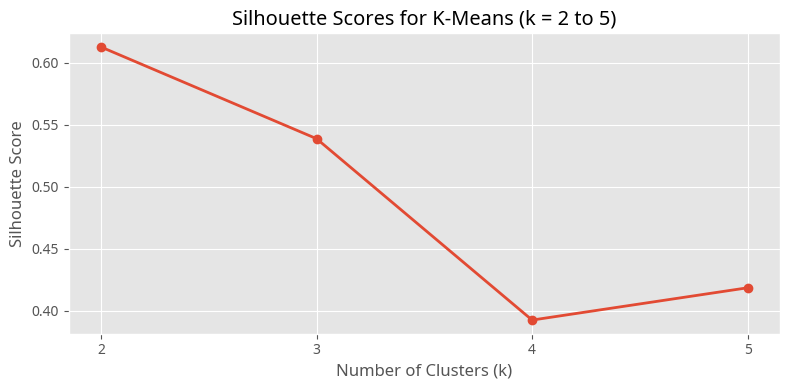

In [6]:
k_values = [2, 3, 4, 5]
silhouette_scores = []

print(f"{'k':>5}  {'Silhouette Score':>20}")
print("-" * 30)

for k in k_values:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = km_temp.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels_temp)
    silhouette_scores.append(score)
    print(f"{k:>5}  {score:>20.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', linewidth=2)
plt.title('Silhouette Scores for K-Means (k = 2 to 5)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.tight_layout()
plt.show()


## 6. Fit Final K-Means Model (k = 3)

We choose k = 3 as it maps naturally to three economically interpretable regimes: **Calm**, **Choppy**, and **Stressed**. We use `random_state=42` for reproducibility and `n_init=10` to run 10 independent initialisations and select the best result.


In [7]:
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
features_df = features_df.copy()
features_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Align clusters back to the main dataframe
df['Cluster'] = np.nan
df.loc[features_df.index, 'Cluster'] = features_df['Cluster']

print(f"K-Means fitted with k={K_FINAL}")
print("Cluster value counts:")
print(features_df['Cluster'].value_counts().sort_index())


K-Means fitted with k=3
Cluster value counts:
Cluster
0    4080
1    1138
2      94
Name: count, dtype: int64


## 7. Cluster Centroids and Economic Labels

We inverse-transform the cluster centroids back to their original units to interpret them. We then assign labels based on the **annualised volatility** of each centroid:

- **Lowest volatility** cluster → **Calm** (low vol, positive momentum, near-zero drawdown)
- **Middle volatility** cluster → **Choppy** (moderate vol, mixed momentum, moderate drawdown)
- **Highest volatility** cluster → **Stressed** (high vol, negative momentum, deep drawdown)

This labelling is deterministic and based on centroid ordering, not manual inspection.


In [8]:
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=FEATURE_COLS,
    index=pd.RangeIndex(K_FINAL, name='Cluster')
)

print("Centroids in original units:")
print(centroids_df.round(4).to_string())

# Assign labels by sorting clusters on Vol_20d (ascending)
sorted_by_vol = centroids_df['Vol_20d'].sort_values().index.tolist()
label_map = {
    sorted_by_vol[0]: 'Calm',
    sorted_by_vol[1]: 'Choppy',
    sorted_by_vol[2]: 'Stressed'
}

df['Regime'] = df['Cluster'].map(label_map)

print()
print("Regime label assignment:")
for cluster_id, regime in label_map.items():
    vol = centroids_df.loc[cluster_id, 'Vol_20d']
    mom = centroids_df.loc[cluster_id, 'Mom_20d']
    dd  = centroids_df.loc[cluster_id, 'Drawdown_60d']
    print(f"  Cluster {cluster_id} -> {regime:8s}  |  Vol={vol:.4f}  Mom={mom:.4f}  DD={dd:.4f}")


Centroids in original units:
         Vol_20d  Mom_20d  Drawdown_60d
Cluster                                
0         0.1211   0.0236       -0.0119
1         0.2379  -0.0347       -0.0867
2         0.7214  -0.1412       -0.2647

Regime label assignment:
  Cluster 0 -> Calm      |  Vol=0.1211  Mom=0.0236  DD=-0.0119
  Cluster 1 -> Choppy    |  Vol=0.2379  Mom=-0.0347  DD=-0.0867
  Cluster 2 -> Stressed  |  Vol=0.7214  Mom=-0.1412  DD=-0.2647


## 8. Validation: Historical Stress Periods

We check the regime distribution during three well-known periods of market stress. We expect the majority of days to be labelled **Stressed** or **Choppy** during these windows.

| Period | Expected Dominant Regime |
|---|---|
| 2008–2009 (Great Financial Crisis) | Stressed |
| March 2020 (COVID-19 crash) | Stressed |
| 2022 (Inflation / Rate Hike Bear Market) | Stressed or Choppy |


In [9]:
stress_periods = {
    'GFC (2008-2009)':       ('2008-01-01', '2009-12-31'),
    'COVID Crash (Mar 2020)': ('2020-03-01', '2020-03-31'),
    '2022 Bear Market':       ('2022-01-01', '2022-12-31'),
}

for name, (start, end) in stress_periods.items():
    mask = (df.index >= start) & (df.index <= end)
    counts = df.loc[mask, 'Regime'].value_counts(normalize=True) * 100
    stressed_choppy_pct = counts.get('Stressed', 0) + counts.get('Choppy', 0)
    print(f"--- {name} ---")
    for regime, pct in counts.items():
        print(f"  {regime:10s}: {pct:.1f}%")
    print(f"  Stressed + Choppy combined: {stressed_choppy_pct:.1f}%")
    print()


--- GFC (2008-2009) ---
  Calm      : 45.5%
  Choppy    : 41.6%
  Stressed  : 12.9%
  Stressed + Choppy combined: 54.5%

--- COVID Crash (Mar 2020) ---
  Stressed  : 77.3%
  Choppy    : 22.7%
  Stressed + Choppy combined: 100.0%

--- 2022 Bear Market ---
  Choppy    : 66.9%
  Calm      : 33.1%
  Stressed + Choppy combined: 66.9%



## 9. Regime Timeline Chart

We plot the SPY closing price (log scale) with the background shaded by the active regime. This provides an intuitive visual check of the clustering results.

- **Green** = Calm
- **Orange** = Choppy
- **Red** = Stressed


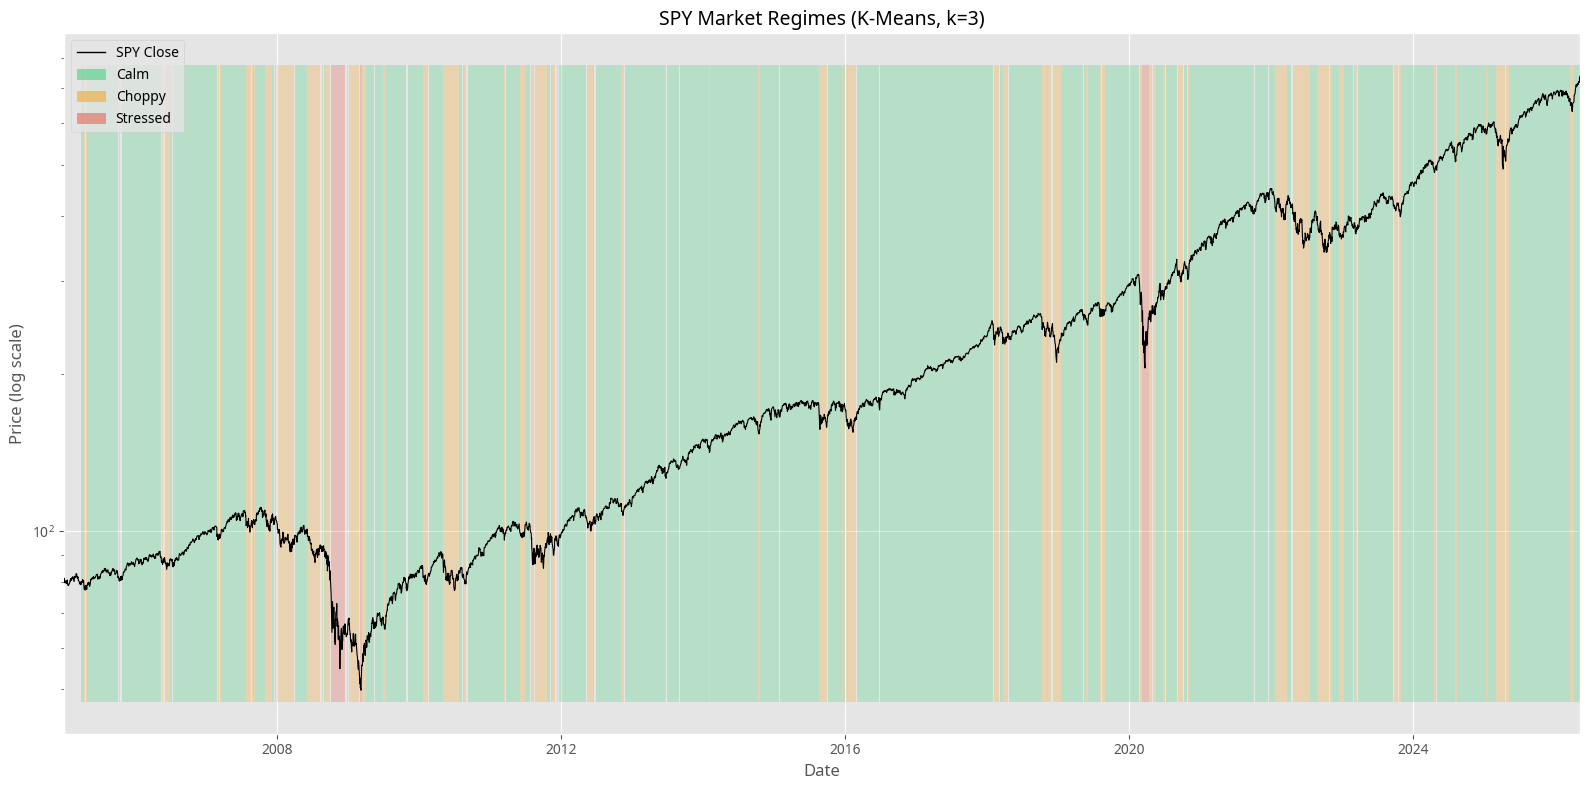

Chart saved to data/regime_timeline.png


In [10]:
REGIME_COLORS = {'Calm': '#2ecc71', 'Choppy': '#f39c12', 'Stressed': '#e74c3c'}

fig, ax = plt.subplots(figsize=(16, 8))

# Plot SPY price
ax.plot(df.index, df['Close'], color='black', linewidth=0.8, zorder=5, label='SPY Close')

# Shade background by regime
for regime, color in REGIME_COLORS.items():
    mask = df['Regime'] == regime
    ax.fill_between(
        df.index,
        df['Close'].min() * 0.95,
        df['Close'].max() * 1.05,
        where=mask,
        color=color,
        alpha=0.25,
        linewidth=0
    )

# Build legend manually
price_line = plt.Line2D([0], [0], color='black', linewidth=1, label='SPY Close')
patches = [mpatches.Patch(color=c, alpha=0.5, label=r) for r, c in REGIME_COLORS.items()]
ax.legend(handles=[price_line] + patches, loc='upper left', fontsize=10)

ax.set_title('SPY Market Regimes (K-Means, k=3)', fontsize=14)
ax.set_ylabel('Price (log scale)')
ax.set_xlabel('Date')
ax.set_yscale('log')
ax.set_xlim(df.index.min(), df.index.max())
plt.tight_layout()
plt.savefig('../data/regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/regime_timeline.png")


## 10. Event Dates Preview (CPI and FOMC)

We load the pre-compiled event dates from `events/event_dates.py` and preview them. These will be used in Phase 2 for event-window analysis.

**Sources:**
- CPI release dates: [BLS CPI release schedule](https://www.bls.gov/cpi/)
- FOMC decision dates: [Federal Reserve FOMC historical materials](https://www.federalreserve.gov/monetarypolicy/fomc_historical_year.htm)


In [11]:
import sys
sys.path.insert(0, '../events')
from event_dates import CPI_DATES, FOMC_DATES

cpi_series  = pd.to_datetime(CPI_DATES)
fomc_series = pd.to_datetime(FOMC_DATES)

print(f"CPI dates loaded:  {len(cpi_series)} entries ({cpi_series.min().date()} to {cpi_series.max().date()})")
print(f"FOMC dates loaded: {len(fomc_series)} entries ({fomc_series.min().date()} to {fomc_series.max().date()})")

# Preview as a combined table
events_df = pd.DataFrame({
    'event_type': ['CPI'] * len(cpi_series) + ['FOMC'] * len(fomc_series),
    'event_date': list(cpi_series) + list(fomc_series),
    'source': ['BLS'] * len(cpi_series) + ['Federal Reserve'] * len(fomc_series)
}).sort_values('event_date').reset_index(drop=True)

print()
print("Sample of event dates (first 10 rows):")
print(events_df.head(10).to_string(index=False))


CPI dates loaded:  180 entries (2010-01-15 to 2024-12-11)
FOMC dates loaded: 122 entries (2010-01-27 to 2024-12-18)

Sample of event dates (first 10 rows):
event_type event_date          source
       CPI 2010-01-15             BLS
      FOMC 2010-01-27 Federal Reserve
       CPI 2010-02-19             BLS
      FOMC 2010-03-16 Federal Reserve
       CPI 2010-03-18             BLS
       CPI 2010-04-14             BLS
      FOMC 2010-04-28 Federal Reserve
       CPI 2010-05-19             BLS
       CPI 2010-06-17             BLS
      FOMC 2010-06-23 Federal Reserve


---
# Phase 1B: Event-Window Analysis

## 11. Align Event Dates to Trading Dates

We load the `CPI_DATES` and `FOMC_DATES` and map them to valid SPY trading dates. 
If an event falls on a weekend or holiday, we take the next available trading day.
We also record the **pre-event regime** (the regime from the trading day immediately before the event) to avoid lookahead bias in grouping.


In [12]:
# df is our main dataframe with SPY data and 'Regime' column
trading_dates = df.index

aligned_events = []

for idx, row in events_df.iterrows():
    ev_type = row['event_type']
    orig_date = pd.to_datetime(row['event_date'])
    
    # Find the nearest trading date on or after the original event date
    valid_dates = trading_dates[trading_dates >= orig_date]
    if len(valid_dates) == 0:
        continue # Event is past our available data
    
    trade_date = valid_dates[0]
    
    # Get the index position of the trading date
    trade_idx = trading_dates.get_loc(trade_date)
    
    # Need at least 1 day before for pre-event regime
    if trade_idx < 1:
        continue
        
    pre_event_date = trading_dates[trade_idx - 1]
    
    pre_event_regime = df.loc[pre_event_date, 'Regime']
    event_day_regime = df.loc[trade_date, 'Regime']
    
    aligned_events.append({
        'event_type': ev_type,
        'original_event_date': orig_date.date(),
        'trading_event_date': trade_date.date(),
        'pre_event_trading_date': pre_event_date.date(),
        'pre_event_regime': pre_event_regime,
        'event_day_regime': event_day_regime
    })

aligned_df = pd.DataFrame(aligned_events)
aligned_df.to_csv('../data/aligned_events.csv', index=False)
print(f"Aligned {len(aligned_df)} events to trading dates.")
aligned_df.head()


Aligned 302 events to trading dates.


,event_type,original_event_date,trading_event_date,pre_event_trading_date,pre_event_regime,event_day_regime
0,CPI,2010-01-15,2010-01-15,2010-01-14,Calm,Calm
1,FOMC,2010-01-27,2010-01-27,2010-01-26,Choppy,Choppy
2,CPI,2010-02-19,2010-02-19,2010-02-18,Choppy,Calm
3,FOMC,2010-03-16,2010-03-16,2010-03-15,Calm,Calm
4,CPI,2010-03-18,2010-03-18,2010-03-17,Calm,Calm


## 12. Extract Event Windows (-5 to +5 Trading Days)

For each aligned event, we extract the daily log returns and simple returns for the window [-5, +5] trading days around the event. Positional indexing is used to strictly count trading days, ignoring weekends and holidays.


In [13]:
window_size = 5
window_records = []

for idx, row in aligned_df.iterrows():
    trade_date = pd.to_datetime(row['trading_event_date'])
    trade_idx = trading_dates.get_loc(trade_date)
    
    # Check if we have enough data bounds for the window
    if trade_idx - window_size < 0 or trade_idx + window_size >= len(trading_dates):
        continue
        
    for i in range(-window_size, window_size + 1):
        curr_idx = trade_idx + i
        curr_date = trading_dates[curr_idx]
        
        log_ret = df.loc[curr_date, 'Log_Return']
        simple_ret = np.exp(log_ret) - 1 # Convert log return back to simple return
        
        window_records.append({
            'event_type': row['event_type'],
            'original_event_date': row['original_event_date'],
            'trading_event_date': row['trading_event_date'],
            'relative_day': i,
            'log_return': log_ret,
            'simple_return': simple_ret,
            'pre_event_regime': row['pre_event_regime'],
            'event_day_regime': row['event_day_regime']
        })

event_windows_df = pd.DataFrame(window_records)
event_windows_df.to_csv('../data/event_windows.csv', index=False)
print(f"Extracted {len(event_windows_df)} daily return records across all event windows.")
event_windows_df.head(11) # Show one full window


Extracted 3322 daily return records across all event windows.


,event_type,original_event_date,trading_event_date,relative_day,log_return,simple_return,pre_event_regime,event_day_regime
0,CPI,2010-01-15,2010-01-15,-5,0.003322,0.003328,Calm,Calm
1,CPI,2010-01-15,2010-01-15,-4,0.001396,0.001396,Calm,Calm
2,CPI,2010-01-15,2010-01-15,-3,-0.009370,-0.009326,Calm,Calm
3,CPI,2010-01-15,2010-01-15,-2,0.008411,0.008446,Calm,Calm
4,CPI,2010-01-15,2010-01-15,-1,0.002701,0.002704,Calm,Calm
5,CPI,2010-01-15,2010-01-15,0,-0.011288,-0.011224,Calm,Calm
6,CPI,2010-01-15,2010-01-15,1,0.012418,0.012496,Calm,Calm
7,CPI,2010-01-15,2010-01-15,2,-0.010221,-0.010169,Calm,Calm
8,CPI,2010-01-15,2010-01-15,3,-0.019416,-0.019229,Calm,Calm
9,CPI,2010-01-15,2010-01-15,4,-0.022544,-0.022292,Calm,Calm


## 13. Compute Event-Study Metrics

We compute summary statistics for each event type grouped by the **pre-event regime**.
Metrics include:
- `N`: Number of events
- `Mean Event-Day Return` (Day 0)
- `Mean Cumulative Return` (Day -5 to +5)
- `Std Event-Day Return`
- `Hit Rate`: % of positive event-day returns
- `Sharpe-like Ratio`: Mean / Std of event-day return

**Important:** Note the sample size `N`. Some regimes (like Stressed) may have very few events, limiting statistical significance.


In [14]:
summary_records = []

for (ev_type, regime), group in event_windows_df.groupby(['event_type', 'pre_event_regime']):
    # Get Day 0 data
    day0 = group[group['relative_day'] == 0]
    n_events = len(day0)
    
    if n_events == 0:
        continue
        
    mean_day0_ret = day0['simple_return'].mean()
    std_day0_ret = day0['simple_return'].std()
    hit_rate = (day0['simple_return'] > 0).mean() * 100
    sharpe_like = mean_day0_ret / std_day0_ret if std_day0_ret > 0 else np.nan
    
    # Calculate average cumulative return path
    # First, group by event and calculate cumulative sum of log returns, then convert to simple
    cum_returns = []
    for orig_date, ev_group in group.groupby('original_event_date'):
        ev_group = ev_group.sort_values('relative_day')
        cum_log = ev_group['log_return'].sum()
        cum_returns.append(np.exp(cum_log) - 1)
        
    mean_cum_ret = np.mean(cum_returns)
    
    summary_records.append({
        'Event Type': ev_type,
        'Pre-Event Regime': regime,
        'N': n_events,
        'Mean Day 0 Ret (%)': mean_day0_ret * 100,
        'Std Day 0 Ret (%)': std_day0_ret * 100,
        'Mean Cum Ret [-5,+5] (%)': mean_cum_ret * 100,
        'Hit Rate (%)': hit_rate,
        'Day 0 Sharpe': sharpe_like
    })

summary_df = pd.DataFrame(summary_records).round(2)
summary_df.to_csv('../data/event_study_summary.csv', index=False)
display(summary_df)


,Event Type,Pre-Event Regime,N,Mean Day 0 Ret (%),Std Day 0 Ret (%),"Mean Cum Ret [-5,+5] (%)",Hit Rate (%),Day 0 Sharpe
0,CPI,Calm,140,0.14,0.70,0.80,60.00,0.20
1,CPI,Choppy,38,-0.25,1.87,-0.32,44.74,-0.14
2,CPI,Stressed,2,-2.89,2.80,-4.12,0.00,-1.03
3,FOMC,Calm,100,0.12,0.90,0.79,55.00,0.13
4,FOMC,Choppy,21,0.24,2.08,-1.83,42.86,0.11
5,FOMC,Stressed,1,-10.94,NaN,-24.61,0.00,NaN


## 14. Visualisations

We generate several visualisations to explore the event windows:
1. **Event-Window Heatmaps** (CPI & FOMC): Mean returns by relative day and regime.
2. **Cumulative Return Paths**: Average cumulative return from Day -5 to +5.
3. **Event-Day Return Boxplots**: Distribution of Day 0 returns by regime.


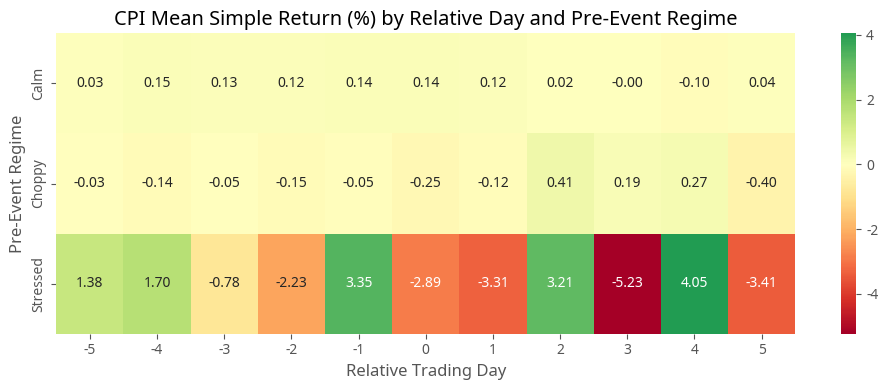

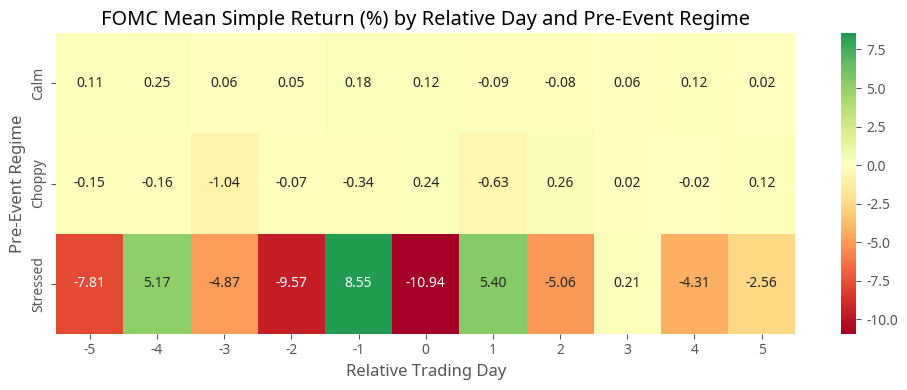

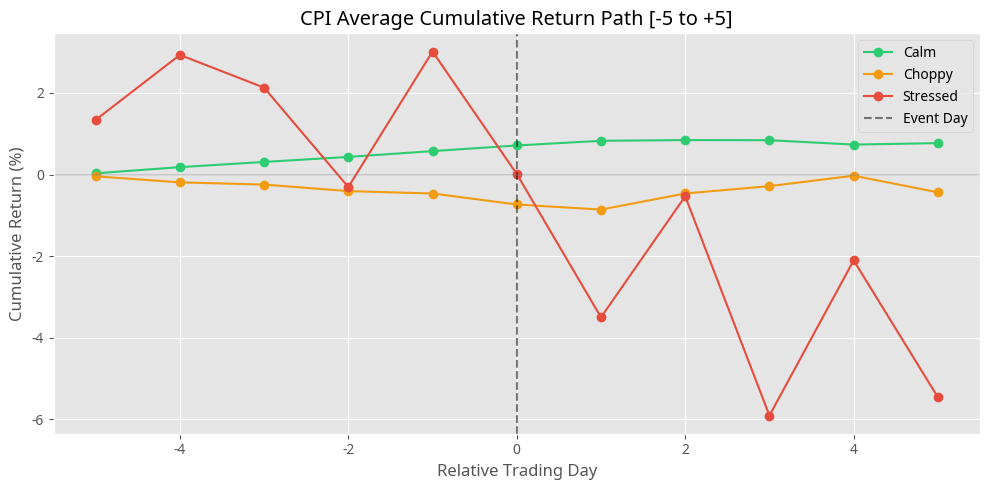

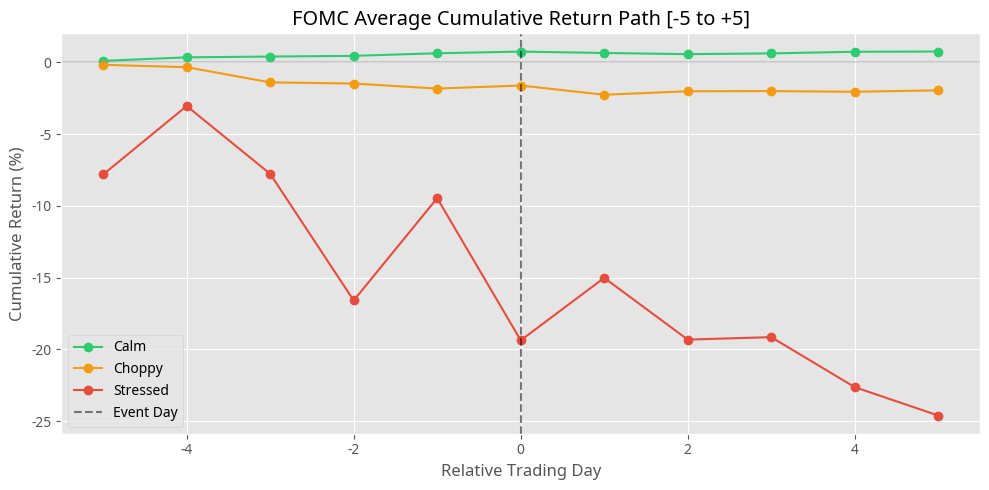

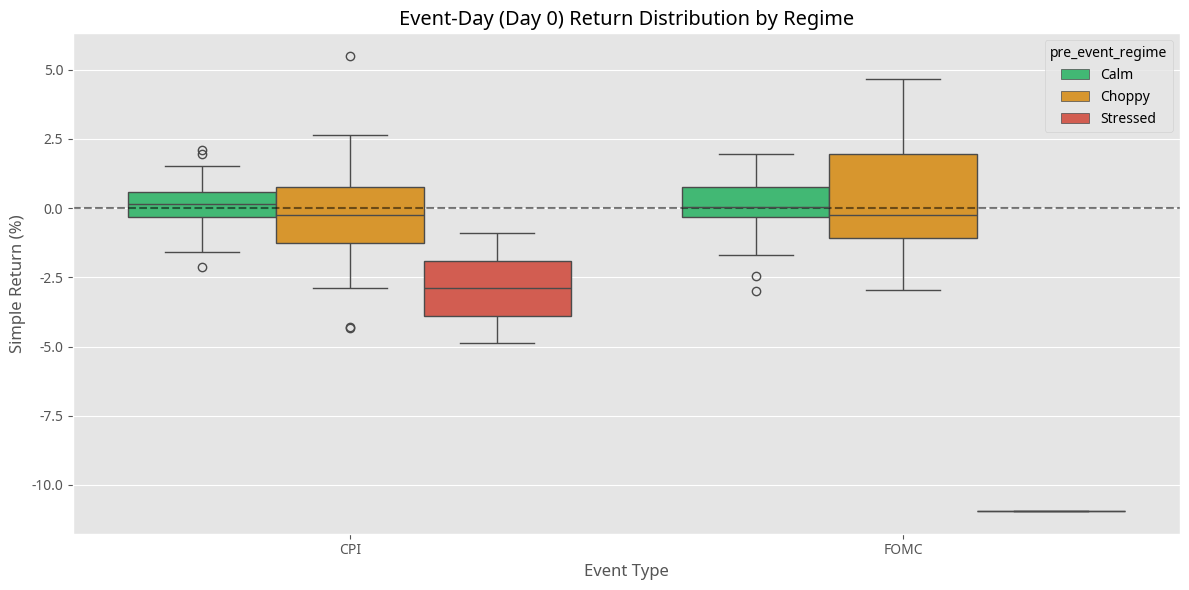

In [15]:
import seaborn as sns

# 1. Heatmaps
for ev_type in ['CPI', 'FOMC']:
    ev_data = event_windows_df[event_windows_df['event_type'] == ev_type]
    if ev_data.empty: continue
        
    pivot = ev_data.pivot_table(
        values='simple_return', 
        index='pre_event_regime', 
        columns='relative_day', 
        aggfunc='mean'
    ) * 100 # Convert to %
    
    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
    plt.title(f'{ev_type} Mean Simple Return (%) by Relative Day and Pre-Event Regime')
    plt.xlabel('Relative Trading Day')
    plt.ylabel('Pre-Event Regime')
    plt.tight_layout()
    plt.savefig(f'../data/{ev_type.lower()}_event_window_heatmap.png', dpi=150)
    plt.show()

# 2. Cumulative Return Paths
for ev_type in ['CPI', 'FOMC']:
    ev_data = event_windows_df[event_windows_df['event_type'] == ev_type]
    if ev_data.empty: continue
        
    plt.figure(figsize=(10, 5))
    for regime in ['Calm', 'Choppy', 'Stressed']:
        regime_data = ev_data[ev_data['pre_event_regime'] == regime]
        if regime_data.empty: continue
            
        # Average log return per relative day, then cumsum, then exp-1
        avg_log_path = regime_data.groupby('relative_day')['log_return'].mean()
        cum_simple_path = (np.exp(avg_log_path.cumsum()) - 1) * 100
        
        plt.plot(cum_simple_path.index, cum_simple_path.values, marker='o', label=regime, color=REGIME_COLORS[regime])
        
    plt.axvline(0, color='black', linestyle='--', alpha=0.5, label='Event Day')
    plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
    plt.title(f'{ev_type} Average Cumulative Return Path [-5 to +5]')
    plt.xlabel('Relative Trading Day')
    plt.ylabel('Cumulative Return (%)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'../data/{ev_type.lower()}_cumulative_event_returns.png', dpi=150)
    plt.show()

# 3. Boxplot of Event-Day Returns
day0_data = event_windows_df[event_windows_df['relative_day'] == 0].copy()
day0_data['simple_return_pct'] = day0_data['simple_return'] * 100

plt.figure(figsize=(12, 6))
sns.boxplot(x='event_type', y='simple_return_pct', hue='pre_event_regime', data=day0_data, palette=REGIME_COLORS)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Event-Day (Day 0) Return Distribution by Regime')
plt.xlabel('Event Type')
plt.ylabel('Simple Return (%)')
plt.tight_layout()
plt.savefig('../data/event_day_return_boxplot.png', dpi=150)
plt.show()


## 15. Saved Outputs
All generated charts and CSVs have been saved to the `data/` directory:
- **Charts:** `cpi_event_window_heatmap.png`, `fomc_event_window_heatmap.png`, `cpi_cumulative_event_returns.png`, `fomc_cumulative_event_returns.png`, `event_day_return_boxplot.png`
- **Data:** `aligned_events.csv`, `event_windows.csv`, `event_study_summary.csv`

## 16. Methodology Notes & Limitations
- **Trading-Day Windows:** Event windows use positional trading-day offsets (-5 to +5), strictly ignoring weekends and holidays.
- **Lookahead Bias Mitigation:** The primary grouping variable is `pre_event_regime` (the regime on Day -1). This ensures that the event day's own return does not influence the regime classification used for grouping.
- **K-Means Caveat:** The K-Means model itself was fit on the full historical dataset. While the features (`Vol_20d`, `Mom_20d`, `Drawdown_60d`) are strictly trailing, the centroids reflect future data. Therefore, these results are **exploratory** and do not constitute a walk-forward trading backtest.
- **Sample Size:** As shown in the summary table, the number of events ($N$) in the `Stressed` regime is often very small. Statistical significance in these buckets is highly limited.
- **No Trading Claims:** This analysis is purely for market observation. It makes no claims of alpha, predictability, or profitability.


---
## Summary

This notebook has completed the Phase 1 foundation:

**Phase 1A:**
1. Downloaded and cached SPY daily data from 2005 onwards.
2. Cleaned the data and computed trailing features (volatility, momentum, drawdown).
3. Clustered the market into **Calm**, **Choppy**, and **Stressed** regimes using K-Means (k=3).
4. Validated regimes against known historical stress periods.
5. Produced a historical regime timeline chart.

**Phase 1B:**
6. Aligned CPI and FOMC event dates to valid SPY trading dates.
7. Extracted [-5, +5] trading-day return windows around each event.
8. Grouped events by their **pre-event regime** to minimize lookahead bias.
9. Computed summary statistics (mean return, hit rate, Sharpe-like ratio) and generated heatmaps, cumulative return paths, and boxplots.
10. Saved all outputs to the `data/` directory for future use.
